# Source Extraction

<img src="https://live.staticflickr.com/65535/54443002259_4a8e1249dd_b.jpg" alt="Embedded Photo" width="500">

*Image generated using ChatGPT.*

## Introduction

Language models tend to lie or tell half-truths, as well as invent facts without providing sources. Nowadays, systems are increasingly used that, instead of answering questions directly, first search a database, e.g., a set of documents, and only then generate an answer based on the best-matching documents. Such an answer is more likely to be grounded in reality and can be verified by a human — provided the correct sources have been found.

Of course, there can be many sources, so search methods must be efficient — processing everything "at once" directly with a language model is out of the question! In this task, you will focus on finding the best sources for a given sentence using the **embedding** method.

Imagine you are an AI engineer at a company developing a tool for verifying scientific facts. Your task is to create a module that can quickly and effectively find reliable scientific publications confirming or disproving specific statements. Thanks to your solution, scientists, journalists, and decision-makers will be able to verify information based on solid scientific foundations, which is particularly important in the era of disinformation.


## Task

Your task is to develop a system that generates high-quality vector representations (embeddings) for both queries and source documents, enabling precise matching of appropriate sources to queries.

Given **queries** and **corpus** (a set of source documents), you must implement functions that assign vectors of real numbers of dimension $768$ to queries and sources. These vectors will be used to find sources for each query using the provided evaluation function, which selects $k=10$ nearest neighbours for a given query from the set of documents.

In your solution, you may use the provided model based on the GPT2 architecture, which has been specially fine-tuned to be helpful in obtaining high-quality embeddings.

While working on the solution, you will be able to test its effectiveness on the validation set, which will allow you to assess the quality of the generated embeddings in the context of finding appropriate source documents.

### Data

The data available to you in this task includes:

- A set of queries for which appropriate sources need to be found
- A document corpus containing scientific publications that can serve as sources for the queries
- Information about query-document matches in the validation set

Your solution will be evaluated on the *SciFact* benchmark. It is used to evaluate fact verification and retrieval systems in a scientific context. It consists of a set of statements (queries) based on real scientific publications, and the document corpus consists of publications in the natural and medical sciences. Each statement has at least one publication that supports or refutes it. We provide code for loading the data, so we only describe the data for information purposes.


**File `corpus.jsonl`** contains unique identifiers, titles, and abstracts of scientific papers.

Example of a single document:
```
{
    "text_id": 13734012,
    "title": "Prevalent abnormal prion protein in human appendixes after bovine spongiform encephalopathy epizootic: large scale survey",
    "text": "OBJECTIVES To carry out a further survey (...) CONCLUSIONS This study corroborates previous studies and suggests a high prevalence of infection with abnormal PrP, indicating vCJD carrier status in the population compared with the 177 vCJD cases to date. These findings have important implications for the management of blood and blood products and for the handling of surgical instruments."
}
```

**File `queries_val.jsonl`** contains the statement texts and the identifier of the matching source text. The test set, on which your solution will ultimately be evaluated, **will not** contain identifiers of matching source texts.

Example of a single query:
```
{
    "query": "1 in 5 million in UK have abnormal PrP positivity.",
    "matching_text_id": 13734012
}
```

### Evaluation Criteria
Your implemented methods (functions) `Embedder.encode_queries` and `Embedder.encode_corpus` will be used to process queries $q \in Q$ and documents $d \in C$ into vectors, respectively. In the following, we will use $q$ and $d$ interchangeably in the context of both texts and their embeddings.

Assume that for a query $q\in Q$ there is a golden document $d\in C$.
The evaluation code sorts all documents by distance from $q$, obtaining documents $K_1, K_2, ..., K_n$, such that $K_1$ is the closest. Then we denote by $I$ the index of the golden document $d$ in this sequence. That is, $I - 1$ is the number of documents whose distance from $q$ is smaller than the distance from $q$ to $d$.

The distance between vectors is calculated using cosine similarity, which for vectors $v, w \in \mathbb{R}^n$ is defined as $\frac{v^Tw}{||v|| \cdot ||w||}$, where $||v||$ is the length of vector $v$.

The score for query $q$ is defined as  

$$\text{nDCG@10}(q) = \begin{cases}
\frac{1}{\log_2(I + 1)} & \text{if $I \leq 10$} \\
0 & \text{otherwise.}
\end{cases}$$

That is, the closer the golden document is placed to the query relative to other documents, the higher the score — if 10 "bad" documents are closer to the query, the score for that example is 0.

The final evaluation of your solution will be based on the **nDCG@10** metric, calculated as the average value of this metric for all queries $(q \in Q )$.

- If the **nDCG@10** score is **lower than 0.2**, you will receive **0 points**.  
- If the score **exceeds 0.5**, you will receive the **maximum number of points**, i.e., **100**.  

Points for values between these thresholds will be awarded proportionally.


## Constraints

- Your solution will be tested on the Competition Platform without internet access and in a GPU environment.
- The evaluation of your final solution on the Competition Platform cannot take longer than 10 minutes with GPU.
- The embedding of each query and text should have dimension 768.
- List of allowed libraries: `torch`, `pandas`, `numpy`, `nltk`, `transformers`.

## Submission Files

You must submit only this notebook completed with your solution (see the `Embedder` class).

## Hints

- The GPT2 model is a decoder-type language model. Decoder-type models work such that for a given sequence of tokens (e.g., a prefix of the processed sentence) $t_1, t_2, \dots, t_n$, they compute a hidden vector $h_{n+1} \in \mathbb{R}^d$, and then transform it with one of their weight matrices to $p_{n+1} \in \mathbb{R}^m$ — a probability distribution over tokens in the vocabulary.
- Compared to the available execution time, there are many documents.

## Evaluation

During testing, the flag `FINAL_EVALUATION_MODE` will be set to `True`.

You can earn between 0 and 100 points for this task. The number of points you earn will be calculated on the (hidden) test set on the Competition Platform based on the above formula, rounded to an integer. If your solution does not meet the above criteria or does not execute correctly, you will receive 0 points for the task.

# Starter Code

In this section, we initialize the environment by importing the necessary libraries and functions. The prepared tokenizer, data loading, and evaluation code will facilitate working with the data and help you solve the task.

In [1]:
######################### DO NOT CHANGE THIS CELL ##########################

FINAL_EVALUATION_MODE = False  # While evaluating your solution, we will change this value to True

In [2]:
######################### DO NOT CHANGE THIS CELL ##########################

import json
import os
from math import log2

import torch
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Tokenizer:
    def __init__(self, tokenizer_path, length=150):
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.tokenizer.padding_side = "right"
        self.length = length

    def __call__(self, batch_text):
        batch_tensor = self.tokenizer(
            batch_text,
            max_length=self.length,
            truncation=True,
            padding=True,
            return_tensors="pt"
        )
        return batch_tensor.to(device)

## Data Loading
In this part of the task, we will load the training data.

In [4]:
######################### DO NOT CHANGE THIS CELL ##########################

def load_corpus(file):
    corpus = {}
    with open(file, encoding="utf8") as f_in:
        for line in f_in:
            line = json.loads(line)
            corpus[line.get("text_id")] = {
                "text": line.get("text"),
                "title": line.get("title"),
            }
    return corpus

def load_queries(file):
    queries = {}
    matching_texts = {}
    with open(file, encoding="utf8") as f_in:
        for query_num, line in enumerate(f_in):
            line = json.loads(line)

            queries[query_num] = line.get("query")
            matching_texts[query_num] = line.get("matching_text_id")
    return queries, matching_texts

corpus = load_corpus("corpus.jsonl")
queries, matching_texts = load_queries("queries_val.jsonl")

print(f"Loaded {len(corpus)} texts and {len(queries)} queries.")

Loaded 5183 texts and 300 queries.


## Evaluation Code

Code similar to the following will be used to evaluate the solution on the test set.

In [5]:
######################### DO NOT CHANGE THIS CELL ##########################

def evaluate_retrieval_ndcg(
    golden_matches: dict[int, int],
    results: dict[int, dict[int, float]],
) -> float:
    """
    Calculates the nDCG metric value for the given search results.

    The function calculates the score of your solution based on the results for the $top\\_k$ best documents according to your embedder.

    :param golden_matches: Dictionary with golden matches, where the key is the query id, and the value is the id of the correct document.
    :param results: Dictionary with search results, where the key is the query id, and the value is a dictionary with document ids and their similarities to the given query.
    :return: nDCG metric value."""

    for query_id, v in results.items():
        results[query_id] = {k: v for k, v in sorted(v.items(), key=lambda item: -item[1])}

    ndcg_sum = 0
    for query_id, v in results.items():
        golden_document = golden_matches[query_id]
        for i, document_id in enumerate(v.keys()):
            if golden_document == document_id:
                ndcg_sum += 1 / log2(i + 2)

    ndcg = round(ndcg_sum / len(results), 5)
    return ndcg


def compute_score(ndcg: float) -> float:
    """
    Calculates the point score based on the nDCG metric value.
    """
    lower_bound = 0.2
    upper_bound = 0.5

    if ndcg <= lower_bound:
        return 0
    elif lower_bound < ndcg < upper_bound:
        return int(round(100 * (ndcg - lower_bound) / (upper_bound - lower_bound)))
    else:
        return 100

### Search
Below is the code used to select the $top\_k$ best documents from the corpus for a given query.

In [6]:
######################### DO NOT CHANGE THIS CELL ##########################

def cos_sim(a: torch.Tensor, b: torch.Tensor):
    """
    Computes the cosine similarity cos_sim(a[i], b[j]) for all i and j.
    :return: Matrix with res[i][j]  = cos_sim(a[i], b[j])
    """
    a_norm = torch.nn.functional.normalize(a, p=2, dim=1)
    b_norm = torch.nn.functional.normalize(b, p=2, dim=1)
    return torch.mm(a_norm, b_norm.transpose(0, 1))

def search_topk_texts(
    embedder,
    corpus: dict[str, dict[str, str]],
    queries: dict[str, str],
    top_k: int = 10,
) -> dict[str, dict[str, float]]:
    results = {}

    # Create embeddings for all queries using model.encode_queries()
    # Runs semantic search against the corpus embeddings
    # Returns a ranked list with the corpus ids
    query_ids = list(queries.keys())
    results = {qid: {} for qid in query_ids}
    queries = [queries[qid] for qid in queries]
    query_embeddings = embedder.encode_queries(queries)

    corpus_ids = sorted(
        corpus,
        key=lambda k: len(corpus[k].get("title", "") + corpus[k].get("text", "")),
        reverse=True,
    )
    corpus = [corpus[cid] for cid in corpus_ids]

    # Encode chunk of corpus
    corpus_embeddings = embedder.encode_corpus(corpus)

    # Compute similarites using cosine-similarity
    cos_scores = cos_sim(query_embeddings, corpus_embeddings)
    cos_scores[torch.isnan(cos_scores)] = -1

    # Get top-k values
    cos_scores_top_k_values, cos_scores_top_k_idx = torch.topk(
        cos_scores,
        min(top_k + 1, len(cos_scores[1])),
        dim=1,
        largest=True,
        sorted=False,
    )
    cos_scores_top_k_values = cos_scores_top_k_values.cpu().tolist()
    cos_scores_top_k_idx = cos_scores_top_k_idx.cpu().tolist()

    for query_itr in range(len(query_embeddings)):
        query_id = query_ids[query_itr]
        for score, corpus_id in zip(cos_scores_top_k_values[query_itr], cos_scores_top_k_idx[query_itr]):
            results[query_id][corpus_ids[corpus_id]] = score

    return results

# Your Solution
In this section, you must place your solution. Make changes only here!

<Axes: ylabel='Count'>

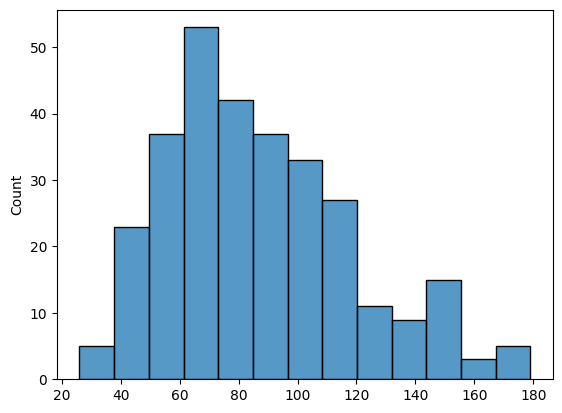

In [19]:
import seaborn as sns
sns.histplot([len(q) for i, q in queries.items()])

In [63]:
class Embedder:
    # Do not change the constructor signature
    def __init__(self):
        # TODO: you can change this method,
        # but do not change its signature! (i.e., do not change the arguments)
        self.model = AutoModel.from_pretrained("Qwen/Qwen3-Embedding-0.6B").cuda()
        self.tokenizer = Tokenizer("Qwen/Qwen3-Embedding-0.6B", 256)

    def last_token_pool(self, last_hidden_states, attention_mask):
        left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
        if left_padding:
            return last_hidden_states[:, -1]
        else:
            sequence_lengths = attention_mask.sum(dim=1) - 1
            batch_size = last_hidden_states.shape[0]
            return last_hidden_states[torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths]

    def encode_queries(self, queries: list[str]):
        """
        Function encoding queries.
        :param queries: List of queries to encode
        :return: Query embeddings - tensor of shape (n, 768), where n = len(queries) is the number of queries.
        """
        BATCH_SIZE = 16
        embeds = []
        queries = ['Given a query, retrieve documents that best answer to that query' + q for q in queries]
        for i in range(0, len(queries), BATCH_SIZE):
            tokenized_queries = self.tokenizer(queries[i:min(i+BATCH_SIZE, len(queries)-1)])
            model_outputs = self.model(**tokenized_queries).last_hidden_state
            batched_query_embeds = self.last_token_pool(model_outputs, tokenized_queries['attention_mask'])
            batched_query_embeds = torch.nn.functional.normalize(batched_query_embeds, dim=1)
            embeds.append(batched_query_embeds)
        
        return torch.cat(embeds).cuda()

    def encode_corpus(self, texts: list[dict]):
        """
        Function encoding source texts.
        :param texts: List of texts to encode. Each text is represented as a dictionary:
            {
                "title": "..."
                "text": "...",
            }
        :return: Text embeddings - tensor of shape (m, 768), where m = len(texts) is the number of texts
        """

        BATCH_SIZE = 16
        embeds = []
        titles = [text['title'] for text in texts]
        for i in range(0, len(texts), BATCH_SIZE):
            tokenized_corpus = self.tokenizer(titles[i:min(i+BATCH_SIZE, len(titles)-1)])
            batched_query_embeds = self.last_token_pool(self.model(**tokenized_corpus).last_hidden_state, tokenized_corpus['attention_mask'])
            batched_query_embeds = torch.nn.functional.normalize(batched_query_embeds, dim=1)
            embeds.append(batched_query_embeds)
        
        return torch.cat(embeds).cuda()

# Evaluation

Running the cell below will allow you to check how many points your solution would score on the validation data. Before submitting, make sure the entire notebook runs from start to finish without errors and without requiring user intervention after selecting the "Run All" option.

In [64]:
######################### DO NOT CHANGE THIS CELL ##########################

if not FINAL_EVALUATION_MODE:
    embedder = Embedder()

    with torch.no_grad():
        results = search_topk_texts(embedder, corpus, queries, top_k=10)

    # Calculate nDCG
    ndcg = evaluate_retrieval_ndcg(matching_texts, results)

    # Calculate final score based on nDCG
    points = compute_score(ndcg)

    print(f"\nNumber of queries: {len(queries)}")
    print(f"Number of texts: {len(corpus)}")
    print(f"nDCG: {ndcg:.3f}")
    print(f"Score: {points}")


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]


Number of queries: 300
Number of texts: 5183
nDCG: 0.603
Score: 100


During testing, the model will be saved as `your_model.pkl` and evaluated on the test set.

In [8]:
######################### DO NOT CHANGE THIS CELL ##########################

if FINAL_EVALUATION_MODE:
    import cloudpickle

    OUTPUT_PATH = "file_output"
    FUNCTION_FILENAME = "your_model.pkl"
    FUNCTION_OUTPUT_PATH = os.path.join(OUTPUT_PATH, FUNCTION_FILENAME)

    if not os.path.exists(OUTPUT_PATH):
        os.makedirs(OUTPUT_PATH)

    with open(FUNCTION_OUTPUT_PATH, "wb") as f:
        cloudpickle.dump(Embedder, f)